In [1]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [2]:
insurance_data = pd.read_csv("insurance.csv")

In [3]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
from sklearn.model_selection import train_test_split

x=insurance_data.drop(columns=['charges'])
y=insurance_data['charges']

x=pd.get_dummies(x,columns=['region'],drop_first=True)

x['sex']=x['sex'].map ({'female':1,'male':0})

x['smoker']=x['smoker'].map ({'yes':1,'no':0})


x['age_smoker'] = x['age'] * x['smoker']

x['bmi_smoker'] = x['bmi'] * x['smoker']



x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [5]:
# apply lasso regression 

lasso_model = Lasso(alpha = 0.5)
lasso_model.fit(x_train,y_train)

y_pred = lasso_model.predict(x_test)

mse = mean_squared_error(y_test,y_pred)

print("mean squared error :", mse)

mean squared error : 20918648.889825605


mean squared error for alpha =  0.001  : 20922599.87103596
mean squared error for alpha =  0.1  : 20921803.698431376
mean squared error for alpha =  1  : 20914832.63508914
mean squared error for alpha =  2  : 20908106.779954515
mean squared error for alpha =  5  : 20890881.000633497
mean squared error for alpha =  10  : 20872844.794796683
mean squared error for alpha =  20  : 20877828.53237883
mean squared error for alpha =  30  : 20937537.133939773
mean squared error for alpha =  40  : 21046489.29389078
mean squared error for alpha =  50  : 21196929.8696089
mean squared error for alpha =  100  : 22423172.686023254


<AxesSubplot:>

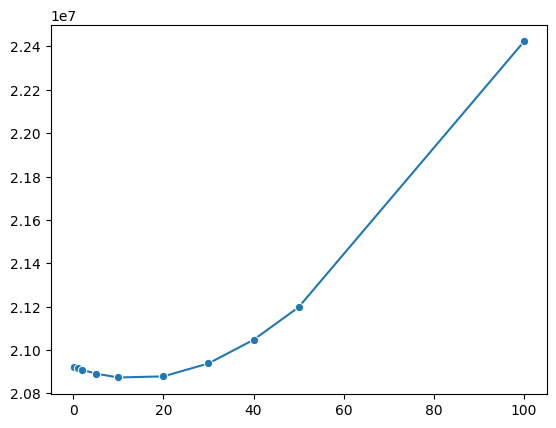

In [6]:
#just for testing 

import seaborn as sns

alphas = [0.001,0.1,1,2,5,10,20,30,40,50,100]
mses = []

for i in alphas:
    
    lasso_model = Lasso(alpha = i)
    lasso_model.fit(x_train,y_train)
    
    y_pred = lasso_model.predict(x_test)
    
    mse = mean_squared_error(y_test,y_pred)
    
    print(f"mean squared error for alpha =  {i}  :", mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker='o')

In [11]:
from sklearn.linear_model import LassoCV

a = [0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model = LassoCV  (
alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(x_train,y_train)

print("best alpha :" , lasso_cv_model.alpha_)

best alpha : 0.001


In [14]:
from sklearn.metrics import r2_score

y_pred = lasso_cv_model.predict(x_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("mse : ",mse)
print("r2 score : ",r2)

mse :  20922599.87103596
r2 score :  0.8652317499151699
